# Notebook 5 — Évaluation de la Robustesse

**Objectif :** Prouver que le biais inductif résout le problème clinique — le **MedVAE Quality-Aware** doit reconstruire les images dégradées mieux que le MedVAE classique.

**Protocole expérimental :**

| Expérience | Description |
|---|---|
| **A — Images réelles** | Comparer baseline vs cVAE sur les images `bad/medium/good` de ARCADE |
| **B — Dégradations synthétiques** | Dégrader artificiellement les meilleures images et comparer la robustesse des deux modèles |

**Métriques :** MSE, SSIM, PSNR

> L'approche de calcul du score `c` est définie dans `pipeline_config.py`. Le checkpoint utilisé correspond à l'approche sélectionnée.

## 0. Configuration

In [1]:
from pathlib import Path
from pipeline_config import APPROACH, get_approach_config, print_approach_summary

print_approach_summary()

NOTEBOOK_DIR  = Path(".").resolve()
PROJECT_ROOT  = Path("/home/infres/nadiedjoa-24/projet_IM06")

OUTPUT_DIR    = Path(f"outputs_theophile/05_Evaluation_of_Robustness/approach_{APPROACH}")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

NB03_DIR      = Path("outputs_theophile/03_Inductive_Bias_Generation")
NB04_DIR      = Path(f"outputs_theophile/04_MedVAE_Architecture_Mod/approach_{APPROACH}")
LABELS_CSV    = NB03_DIR / "labels_quality.csv"
CVAE_CKPT     = NB04_DIR / "quality_aware_vae.pt"

DDCONFIG = {
    "double_z": True, "z_channels": 4, "resolution": 64,
    "in_channels": 1, "out_ch": 1, "ch": 128,
    "ch_mult": [1, 2, 4], "num_res_blocks": 2,
    "attn_resolutions": [], "dropout": 0.0,
}
EMBED_DIM = 4
IMG_SIZE  = DDCONFIG["resolution"]

N_TEST_PER_CLASS = 20
RANDOM_SEED      = 42

print(f"Checkpoint : {CVAE_CKPT}  (existe: {CVAE_CKPT.exists()})")
print(f"Sorties    : {OUTPUT_DIR}")

╔══════════════════════════════════════════════════════════╗
║  Approche : B — PCA (PC1)                                   ║
╚══════════════════════════════════════════════════════════╝
  Colonne de score : score_pca
  Premier composant principal normalisé [0,1], signe corrigé par corrélation avec Tenengrad. Objectif, data-driven.

Checkpoint : outputs_theophile/04_MedVAE_Architecture_Mod/approach_B/quality_aware_vae.pt  (existe: True)
Sorties    : outputs_theophile/05_Evaluation_of_Robustness/approach_B


## 1. Imports

In [2]:
import sys, warnings, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm
from scipy import stats
from scipy.ndimage import uniform_filter
from skimage.metrics import structural_similarity as ssim_fn
from skimage.metrics import peak_signal_noise_ratio as psnr_fn

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings("ignore")
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

from medvae_standalone import AutoencoderKL as AutoencoderKL2D
from medvae_standalone import DiagonalGaussianDistribution

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {DEVICE}")

/home/infres/nadiedjoa-24/.local/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.5' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/usr/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device : cuda


## 2. Définition de QualityAwareAutoencoderKL (FiLM)

*(Redéfinie ici pour rendre ce notebook autonome — version FiLM identique au Notebook 4)*

In [3]:
class FiLMConditioner(nn.Module):
    """FiLM — Perez et al., AAAI 2018. Zero-init."""
    def __init__(self, channels_per_block: list, hidden_dim: int = 128):
        super().__init__()
        self.embed = nn.Sequential(
            nn.Linear(1, hidden_dim), nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim), nn.SiLU(),
        )
        self.heads = nn.ModuleList()
        for ch in channels_per_block:
            head = nn.Linear(hidden_dim, 2 * ch)
            nn.init.zeros_(head.weight)
            nn.init.zeros_(head.bias)
            self.heads.append(head)

    def forward(self, c):
        emb = self.embed(c.view(-1, 1))
        return [
            (gb[:, :gb.shape[1]//2].unsqueeze(-1).unsqueeze(-1),
             gb[:, gb.shape[1]//2:].unsqueeze(-1).unsqueeze(-1))
            for gb in (head(emb) for head in self.heads)
        ]


class QualityAwareAutoencoderKL(nn.Module):
    """cVAE conditionné via FiLM (hooks sur chaque ResnetBlock)."""
    def __init__(self, base_ae: AutoencoderKL2D):
        super().__init__()
        self.ae = base_ae
        self._blocks = list(self._iter_resnet_blocks())
        channels = [b.conv2.out_channels for b in self._blocks]
        self.film = FiLMConditioner(channels)

    def _iter_resnet_blocks(self):
        enc = self.ae.encoder
        for i_level in range(enc.num_resolutions):
            for i_block in range(enc.num_res_blocks):
                yield enc.down[i_level].block[i_block]
        yield enc.mid.block_1
        yield enc.mid.block_2
        dec = self.ae.decoder
        yield dec.mid.block_1
        yield dec.mid.block_2
        for i_level in reversed(range(dec.num_resolutions)):
            for i_block in range(dec.num_res_blocks + 1):
                yield dec.up[i_level].block[i_block]

    def _register_film_hooks(self, c):
        film_params = self.film(c)
        hooks = []
        for i, block in enumerate(self._blocks):
            gamma, beta = film_params[i]
            hook = block.register_forward_hook(
                lambda mod, inp, out, g=gamma, b=beta: (1 + g) * out + b
            )
            hooks.append(hook)
        return hooks

    def forward(self, x, c, sample_posterior=True):
        hooks = self._register_film_hooks(c)
        try:
            h = self.ae.encoder(x)
            moments = self.ae.quant_conv(h)
            posterior = DiagonalGaussianDistribution(moments)
            z = posterior.sample() if sample_posterior else posterior.mode()
            dec = self.ae.decoder(self.ae.post_quant_conv(z))
        finally:
            for hk in hooks:
                hk.remove()
        return dec, posterior

    def get_last_layer(self):
        return self.ae.get_last_layer()


print("QualityAwareAutoencoderKL définie (FiLM).")

QualityAwareAutoencoderKL définie (FiLM).


## 3. Chargement des deux modèles

- **cVAE** : MedVAE fine-tuné sur ARCADE **avec** conditionnement FiLM (Notebook 4)
- **Baseline** : MedVAE fine-tuné sur ARCADE **sans** conditionnement (même données, même budget compute, même hyperparamètres — ablation propre entraînée dans NB04)

In [4]:
def load_cvae(ckpt_path: Path) -> QualityAwareAutoencoderKL:
    ckpt    = torch.load(ckpt_path, map_location="cpu", weights_only=False)
    base_ae = AutoencoderKL2D(ddconfig=ckpt["ddconfig"], embed_dim=ckpt["embed_dim"],
                               apply_channel_ds=True)
    model   = QualityAwareAutoencoderKL(base_ae)
    model.load_state_dict(ckpt["model_state_dict"])
    return model, ckpt

if CVAE_CKPT.exists():
    cvae, ckpt_data = load_cvae(CVAE_CKPT)
    cvae = cvae.to(DEVICE).eval()
    print(f"cVAE       : {sum(p.numel() for p in cvae.parameters()):,} paramètres")
    print(f"Checkpoint : {CVAE_CKPT.name}")
else:
    print("[!] Checkpoint introuvable — instanciation à froid (poids aléatoires).")
    base_ae2 = AutoencoderKL2D(ddconfig=DDCONFIG, embed_dim=EMBED_DIM, apply_channel_ds=True)
    cvae = QualityAwareAutoencoderKL(base_ae2).to(DEVICE).eval()
    ckpt_data = {}

baseline = AutoencoderKL2D(
    ddconfig=DDCONFIG, embed_dim=EMBED_DIM, apply_channel_ds=True,
).to(DEVICE)

if "baseline_state_dict" in ckpt_data:
    baseline.load_state_dict(ckpt_data["baseline_state_dict"])
    bl_steps = ckpt_data.get("baseline_steps", "?")
    bl_val   = ckpt_data.get("best_val_loss_baseline", "?")
    print(f"Baseline   : VAE fine-tuné sur ARCADE SANS FiLM ({bl_steps} steps, val_loss={bl_val}) ✓")
elif CVAE_CKPT.exists():
    PRETRAINED_CKPT = Path("outputs_theophile/pretrained_weights/vae_4x_4c_2D.ckpt")
    if "pretrained_state_dict" in ckpt_data:
        baseline.load_state_dict(ckpt_data["pretrained_state_dict"])
        print("⚠ baseline_state_dict absent — fallback sur poids pré-entraînés.")
        print("  → Relancez le Notebook 4 pour générer le vrai baseline (ablation).")
    elif PRETRAINED_CKPT.exists():
        baseline_fresh = AutoencoderKL2D(
            ddconfig=DDCONFIG, embed_dim=EMBED_DIM,
            ckpt_path=PRETRAINED_CKPT, apply_channel_ds=True,
        )
        baseline.load_state_dict(baseline_fresh.state_dict())
        del baseline_fresh
        print(f"⚠ baseline_state_dict absent — fallback sur {PRETRAINED_CKPT.name}.")
        print("  → Relancez le Notebook 4 pour générer le vrai baseline (ablation).")
    else:
        print("⚠ Aucun baseline trouvé. Relancez le Notebook 4.")
else:
    print("⚠ Checkpoint introuvable — baseline avec poids aléatoires.")

baseline.eval()
print(f"Baseline   : {sum(p.numel() for p in baseline.parameters()):,} paramètres")
print(f"\n→ Comparaison rigoureuse : fine-tuné AVEC c (cVAE+FiLM) vs fine-tuné SANS c (ablation)")

cVAE       : 57,059,837 paramètres
Checkpoint : quality_aware_vae.pt
Baseline   : VAE fine-tuné sur ARCADE SANS FiLM (7500 steps, val_loss=0.013460289165377616) ✓
Baseline   : 55,358,845 paramètres

→ Comparaison rigoureuse : fine-tuné AVEC c (cVAE+FiLM) vs fine-tuné SANS c (ablation)


## 4. Construction des sets de test

In [5]:
df_labels = pd.read_csv(LABELS_CSV)
print(f"Dataset : {len(df_labels)} images  —  labels : {df_labels['quality_label'].value_counts().to_dict()}")

test_sets = {}
for label in ["bad", "medium", "good"]:
    subset = df_labels[df_labels["quality_label"] == label]
    accessible = subset[subset["path"].apply(lambda p: Path(p).exists())]
    sampled    = accessible.sample(min(N_TEST_PER_CLASS, len(accessible)),
                                    random_state=RANDOM_SEED)
    test_sets[label] = sampled.reset_index(drop=True)
    print(f"  {label:6s} : {len(sampled):3d} images accessibles")

df_test = pd.concat(test_sets.values(), ignore_index=True)
print(f"\nTotal : {len(df_test)} images de test")

Dataset : 1200 images  —  labels : {'medium': 423, 'good': 401, 'bad': 376}
  bad    :  20 images accessibles
  medium :  20 images accessibles
  good   :  20 images accessibles

Total : 60 images de test


## 5. Fonctions utilitaires

### 5a. Chargement et prétraitement

In [6]:
def load_tensor(path: str, size: int = IMG_SIZE) -> torch.Tensor:
    """Charge une image → FloatTensor (1, 1, H, W) dans [-1, 1]."""
    img = Image.open(path).convert("L").resize((size, size), Image.Resampling.BILINEAR)
    t   = torch.from_numpy(np.asarray(img, np.float32) / 255.0)
    return (t.unsqueeze(0).unsqueeze(0) * 2.0 - 1.0)


def to_uint8(t: torch.Tensor) -> np.ndarray:
    """Tenseur [-1,1] (1,1,H,W) → np.uint8 (H,W) pour les métriques skimage."""
    arr = t.squeeze().cpu().numpy()
    return ((arr.clip(-1, 1) + 1) / 2 * 255).astype(np.uint8)

### 5b. Métriques de reconstruction

| Métrique | Description | Sens |
|---|---|---|
| **MSE** | Erreur quadratique moyenne pixel-à-pixel | ↓ meilleur |
| **SSIM** | Structural Similarity Index | ↑ meilleur |
| **PSNR** | Peak Signal-to-Noise Ratio | ↑ meilleur |
| **HaarPSI** | Haar Perceptual Similarity Index (ondelettes) | ↑ meilleur |

> **Note scientifique (SSIM / PSNR) :** Bien que le SSIM et le PSNR soient calculés ici par convention,
> des études récentes (Breger et al., 2024 — *A study on the adequacy of common IQA measures for
> medical images*) montrent que ces métriques sont **faiblement corrélées à la qualité perçue**
> sur les rayons X cardiaques et pulmonaires. La métrique **HaarPSI**, basée sur les ondelettes de Haar,
> s'est révélée significativement plus fiable dans cette étude. L'analyse visuelle et le MSE
> sur l'anatomie restent nos indicateurs primaires ; le HaarPSI sert de validation perceptuelle.

In [7]:
def compute_metrics(original: torch.Tensor, reconstruction: torch.Tensor) -> dict:
    """
    original, reconstruction : (1, 1, H, W) dans [-1, 1]
    Retourne MSE, SSIM, PSNR, HaarPSI.
    """
    mse  = float(F.mse_loss(reconstruction, original).item())

    orig_u8 = to_uint8(original)
    rec_u8  = to_uint8(reconstruction)

    ssim_val = float(ssim_fn(orig_u8, rec_u8, data_range=255))
    psnr_val = float(psnr_fn(orig_u8, rec_u8, data_range=255))

    haarpsi_val = _compute_haarpsi(orig_u8, rec_u8)

    return {"mse": mse, "ssim": ssim_val, "psnr": psnr_val, "haarpsi": haarpsi_val}


def _compute_haarpsi(ref: np.ndarray, deg: np.ndarray) -> float:
    """
    HaarPSI simplifié via ondelettes de Haar à 2 échelles.
    Tente d'abord la bibliothèque `piq`, puis fallback numpy.
    """
    try:
        import piq
        r_t = torch.from_numpy(ref.astype(np.float32)).unsqueeze(0).unsqueeze(0)
        d_t = torch.from_numpy(deg.astype(np.float32)).unsqueeze(0).unsqueeze(0)
        return float(piq.haarpsi(r_t, d_t, data_range=255.).item())
    except (ImportError, Exception):
        pass

    from scipy.ndimage import convolve, zoom

    C = 3e-4
    ref64 = ref.astype(np.float64) / 255.0
    deg64 = deg.astype(np.float64) / 255.0

    total_score, total_weight = 0.0, 0.0
    for scale in [1, 2]:
        if scale > 1:
            r = zoom(ref64, 0.5, order=1)
            d = zoom(deg64, 0.5, order=1)
        else:
            r, d = ref64, deg64

        for kernel in [np.array([[1, -1]], dtype=np.float64),
                       np.array([[1], [-1]], dtype=np.float64)]:
            cr = np.abs(convolve(r, kernel, mode="reflect"))
            cd = np.abs(convolve(d, kernel, mode="reflect"))
            sim = (2 * cr * cd + C) / (cr**2 + cd**2 + C)
            w = np.maximum(cr, cd)
            total_score  += np.sum(w * sim)
            total_weight += np.sum(w)

    return float(total_score / (total_weight + 1e-10))


print("compute_metrics défini (MSE, SSIM, PSNR, HaarPSI).")

compute_metrics défini (MSE, SSIM, PSNR, HaarPSI).


### 5c. Score de qualité inline (pour les images dégradées synthétiquement)

In [8]:
def inline_quality_score(img_tensor: torch.Tensor) -> float:
    """
    Calcule un score de qualité ∈ [0,1] directement depuis un tenseur.
    Utilise Tenengrad + Laplacian variance après normalisation MSCN.
    Reproduit la logique du Notebook 2 (référence : méthode A du Notebook 3).

    Un pré-lissage gaussien (σ=1 px) rend le score robuste au bruit :
    la structure est préservée mais le bruit HF est atténué avant calcul.
    Un terme de pénalité bruit (résidu HF) empêche la saturation à 1.0.
    """
    from scipy.ndimage import laplace, sobel, gaussian_filter

    img = img_tensor.squeeze().cpu().numpy().astype(np.float64)
    img = (img + 1) / 2

    img_smooth = gaussian_filter(img, sigma=1.0)

    mu    = uniform_filter(img_smooth, size=7)
    sigma = np.sqrt(np.maximum(uniform_filter(img_smooth**2, size=7) - mu**2, 0))
    mscn  = (img_smooth - mu) / (sigma + 1.0)

    lap_var   = float(laplace(mscn).var())
    Gx        = sobel(mscn, axis=1)
    Gy        = sobel(mscn, axis=0)
    tenengrad = float(np.sqrt(Gx**2 + Gy**2).mean())

    noise_energy = float(np.mean((img - img_smooth) ** 2))
    noise_penalty = float(np.clip(1.0 - noise_energy / 0.005, 0.0, 1.0))

    raw_score = np.clip(0.5 * (lap_var / 0.01) + 0.5 * (tenengrad / 0.5), 0.0, 1.0)
    score = raw_score * noise_penalty
    return float(score)

if len(df_test) > 0:
    x_check = load_tensor(df_test["path"].iloc[0])
    print(f"Score qualité inline (exemple) : {inline_quality_score(x_check):.4f}")

Score qualité inline (exemple) : 0.0425


## 6. Dégradations synthétiques

Pour un benchmark contrôlé, on dégrade artificiellement les meilleures images ARCADE.  
Cela reproduit la méthodologie validée dans le papier 3 (Cryptosporidium IQA, 2026).

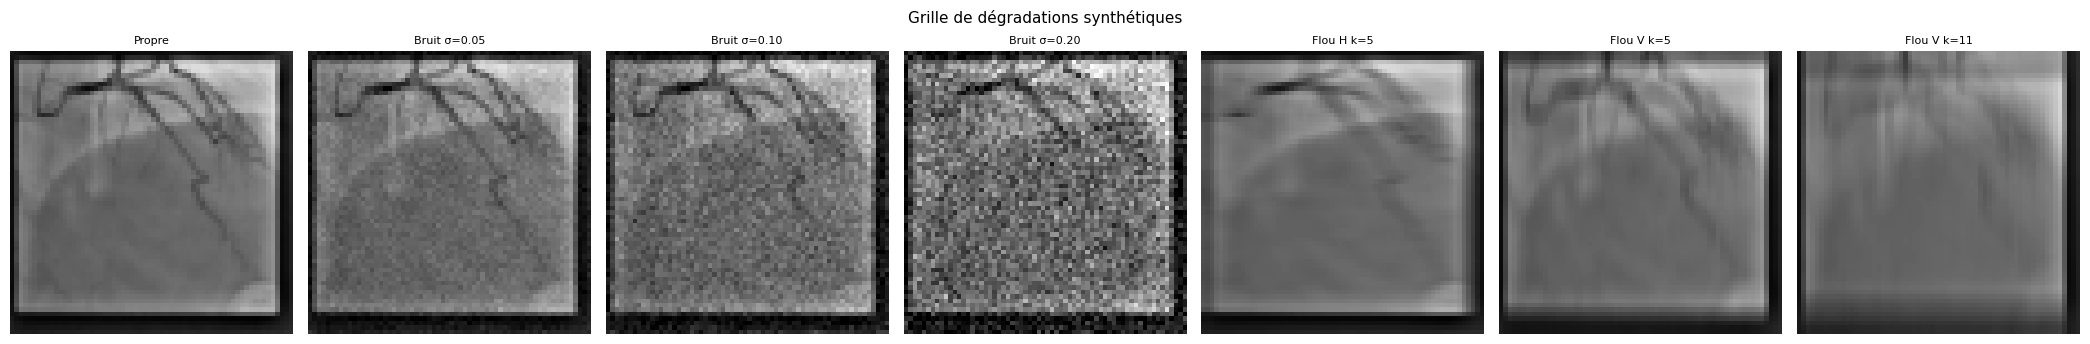

In [9]:
def add_gaussian_noise(x: torch.Tensor, sigma: float) -> torch.Tensor:
    return (x + torch.randn_like(x) * sigma).clamp(-1, 1)


def add_motion_blur(x: torch.Tensor, kernel_size: int, direction: str = "horizontal") -> torch.Tensor:
    """Simule le flou de mouvement cardiaque (direction verticale prédominante)."""
    if direction == "horizontal":
        k = torch.ones(1, 1, 1, kernel_size, device=x.device) / kernel_size
        pad = (kernel_size // 2, kernel_size // 2, 0, 0)
    else:
        k = torch.ones(1, 1, kernel_size, 1, device=x.device) / kernel_size
        pad = (0, 0, kernel_size // 2, kernel_size // 2)
    return F.conv2d(F.pad(x, pad, mode="reflect"), k).clamp(-1, 1)


DEGRADATION_GRID = [
    {"name": "Propre",          "fn": lambda x: x,                             "severity": 0.0},
    {"name": "Bruit σ=0.05",   "fn": lambda x: add_gaussian_noise(x, 0.05),   "severity": 0.05},
    {"name": "Bruit σ=0.10",   "fn": lambda x: add_gaussian_noise(x, 0.10),   "severity": 0.10},
    {"name": "Bruit σ=0.20",   "fn": lambda x: add_gaussian_noise(x, 0.20),   "severity": 0.20},
    {"name": "Flou H k=5",     "fn": lambda x: add_motion_blur(x, 5,  "horizontal"), "severity": 5},
    {"name": "Flou V k=5",     "fn": lambda x: add_motion_blur(x, 5,  "vertical"),   "severity": 5},
    {"name": "Flou V k=11",    "fn": lambda x: add_motion_blur(x, 11, "vertical"),   "severity": 11},
]

if len(test_sets.get("good", pd.DataFrame())) > 0:
    x_demo = load_tensor(test_sets["good"]["path"].iloc[0]).to(DEVICE)

    fig, axes = plt.subplots(1, len(DEGRADATION_GRID), figsize=(3 * len(DEGRADATION_GRID), 3.5))
    for ax, d in zip(axes, DEGRADATION_GRID):
        with torch.no_grad():
            x_deg = d["fn"](x_demo)
        ax.imshow(to_uint8(x_deg), cmap="gray", vmin=0, vmax=255)
        ax.set_title(d["name"], fontsize=8)
        ax.axis("off")
    fig.suptitle("Grille de dégradations synthétiques", fontsize=11)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "05_degradation_grid.png", dpi=120, bbox_inches="tight")
    plt.show()

## 7. Évaluation quantitative — images réelles

On évalue les deux modèles sur les images `bad/medium/good` du jeu de test.  
Le cVAE utilise le `quality_score` réel de chaque image.

In [10]:
@torch.no_grad()
def evaluate_on_dataframe(df: pd.DataFrame, label: str) -> pd.DataFrame:
    records = []
    for _, row in tqdm(df.iterrows(), total=len(df), desc=f"{label:6s}", leave=False):
        try:
            x = load_tensor(row["path"]).to(DEVICE)
            c = torch.tensor([row["quality_score"]], dtype=torch.float32, device=DEVICE)

            rec_base, post_base, _ = baseline(x, sample_posterior=False, decode=True)
            m_base = compute_metrics(x, rec_base)

            rec_cvae, post_cvae = cvae(x, c, sample_posterior=False)
            m_cvae = compute_metrics(x, rec_cvae)

            records.append({
                "image_id":      row["image_id"],
                "path":          row["path"],
                "quality_label": label,
                "quality_score": row["quality_score"],
                **{f"base_{k}": v for k, v in m_base.items()},
                **{f"cvae_{k}": v for k, v in m_cvae.items()},
            })
        except Exception as e:
            pass
    return pd.DataFrame(records)


results_per_label = {}
for label, df_subset in test_sets.items():
    results_per_label[label] = evaluate_on_dataframe(df_subset, label)

df_results = pd.concat(results_per_label.values(), ignore_index=True)
print(f"\nÉvaluation terminée : {len(df_results)} images")
df_results.groupby("quality_label")[["base_mse", "cvae_mse", "base_ssim", "cvae_ssim", "base_haarpsi", "cvae_haarpsi"]].mean().round(5)


Évaluation terminée : 60 images


,base_mse,cvae_mse,base_ssim,cvae_ssim,base_haarpsi,cvae_haarpsi
quality_label,,,,,,
bad,0.00190,0.00215,0.93588,0.92415,0.89624,0.87313
good,0.00273,0.00375,0.92733,0.90491,0.88846,0.84309
medium,0.00157,0.00193,0.93596,0.92184,0.89435,0.87077


## 8. Évaluation sur images synthétiquement dégradées

On part des meilleures images (ground truth connue) et on mesure MSE de reconstruction  
par rapport à l'image **propre originale** — pas à l'image dégradée.

In [11]:
@torch.no_grad()
def evaluate_synthetic(df_good: pd.DataFrame) -> pd.DataFrame:
    records = []
    for _, row in tqdm(df_good.iterrows(), total=len(df_good), desc="Synthetic", leave=False):
        try:
            x_clean = load_tensor(row["path"]).to(DEVICE)
        except Exception:
            continue

        for d in DEGRADATION_GRID:
            x_deg = d["fn"](x_clean)
            c_deg = torch.tensor([inline_quality_score(x_deg)], device=DEVICE)

            rec_base, _, _ = baseline(x_deg, sample_posterior=False, decode=True)
            rec_cvae, _    = cvae(x_deg, c_deg, sample_posterior=False)

            m_base = compute_metrics(x_clean, rec_base)
            m_cvae = compute_metrics(x_clean, rec_cvae)

            records.append({
                "image_id":    row["image_id"],
                "degradation": d["name"],
                "severity":    d["severity"],
                "c_inline":    float(c_deg.item()),
                **{f"base_{k}": v for k, v in m_base.items()},
                **{f"cvae_{k}": v for k, v in m_cvae.items()},
            })
    return pd.DataFrame(records)


df_synth = evaluate_synthetic(test_sets.get("good", pd.DataFrame()))
print(f"Images synthétiques évaluées : {len(df_synth)} entrées")
if len(df_synth):
    df_synth.groupby("degradation")[["base_mse", "cvae_mse", "base_ssim", "cvae_ssim", "base_haarpsi", "cvae_haarpsi"]].mean().round(5)

Images synthétiques évaluées : 140 entrées


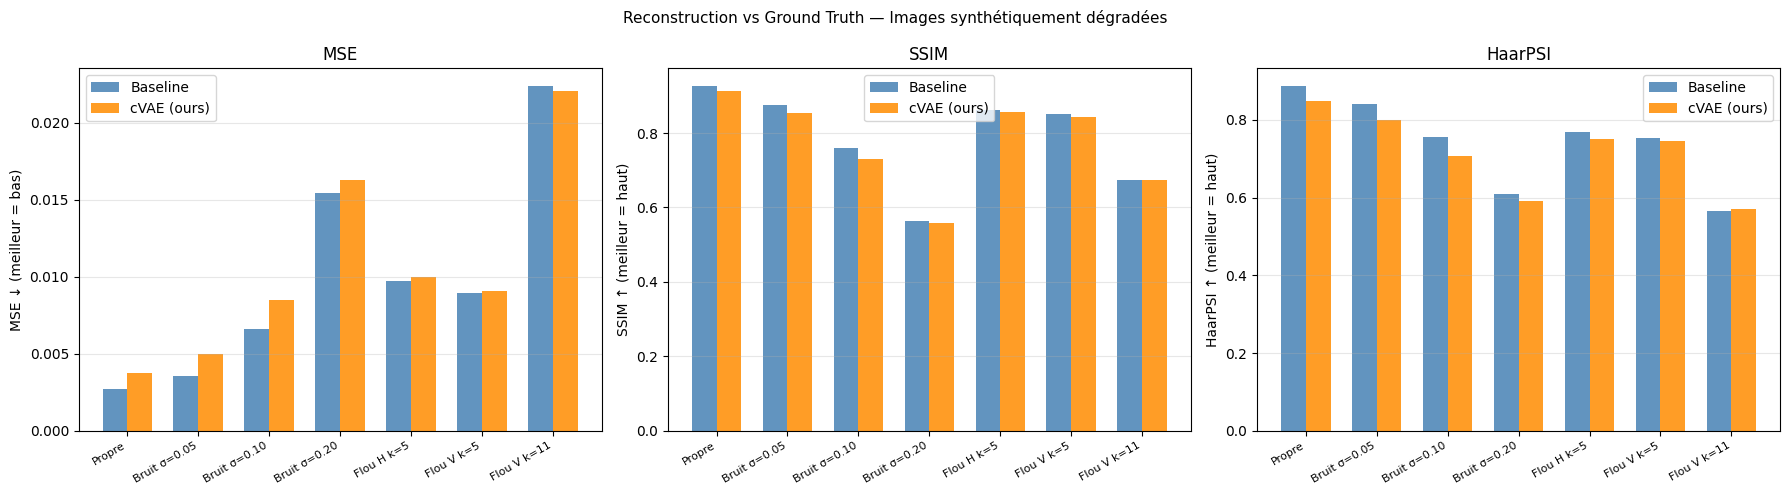

In [12]:
if len(df_synth) > 0:
    order   = [d["name"] for d in DEGRADATION_GRID]
    grouped = df_synth.groupby("degradation")[["base_mse", "cvae_mse"]].mean().reindex(order)

    x_pos = np.arange(len(order))
    width = 0.35
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    for ax, metric, ylabel in zip(
        axes,
        [["base_mse", "cvae_mse"], ["base_ssim", "cvae_ssim"], ["base_haarpsi", "cvae_haarpsi"]],
        ["MSE ↓ (meilleur = bas)", "SSIM ↑ (meilleur = haut)", "HaarPSI ↑ (meilleur = haut)"],
    ):
        g = df_synth.groupby("degradation")[metric].mean().reindex(order)
        bars1 = ax.bar(x_pos - width/2, g[metric[0]], width, label="Baseline",   color="steelblue",   alpha=0.85)
        bars2 = ax.bar(x_pos + width/2, g[metric[1]], width, label="cVAE (ours)", color="darkorange", alpha=0.85)
        ax.set_xticks(x_pos)
        ax.set_xticklabels(order, rotation=30, ha="right", fontsize=8)
        ax.set_ylabel(ylabel)
        ax.legend()
        ax.set_title(ylabel.split(" ")[0])
        ax.grid(axis="y", alpha=0.3)

    fig.suptitle("Reconstruction vs Ground Truth — Images synthétiquement dégradées", fontsize=11)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "05_synthetic_metrics.png", dpi=120, bbox_inches="tight")
    plt.show()

## 9. Comparaison statistique

On teste si la différence de performance est **statistiquement significative** sur les images `bad`.  
Test de Wilcoxon (non-paramétrique, robuste pour petits effectifs).

In [13]:
for metric, direction in [("mse", "↓ meilleur = bas"), ("ssim", "↑ meilleur = haut"), ("psnr", "↑ meilleur = haut"), ("haarpsi", "↑ meilleur = haut")]:
    print(f"\n{'='*60}")
    print(f"Métrique : {metric.upper()} ({direction})")
    print(f"{'='*60}")
    print(f"{'Label':8s}  {'Baseline':>12s}  {'cVAE':>12s}  {'Δ':>10s}  {'p-value':>10s}")

    for label in ["bad", "medium", "good"]:
        sub = df_results[df_results["quality_label"] == label]
        if len(sub) < 2:
            continue
        base_vals = sub[f"base_{metric}"].values
        cvae_vals = sub[f"cvae_{metric}"].values

        mean_b = np.mean(base_vals)
        mean_c = np.mean(cvae_vals)
        delta  = mean_c - mean_b

        try:
            stat, pval = stats.wilcoxon(base_vals, cvae_vals)
        except Exception:
            pval = float("nan")

        sig = "✓ sig." if (not np.isnan(pval) and pval < 0.05) else "—"
        print(f"{label:8s}  {mean_b:12.5f}  {mean_c:12.5f}  {delta:+10.5f}  {pval:10.4f}  {sig}")


Métrique : MSE (↓ meilleur = bas)
Label         Baseline          cVAE           Δ     p-value
bad            0.00190       0.00215    +0.00025      0.0192  ✓ sig.
medium         0.00157       0.00193    +0.00036      0.0000  ✓ sig.
good           0.00273       0.00375    +0.00101      0.0001  ✓ sig.

Métrique : SSIM (↑ meilleur = haut)
Label         Baseline          cVAE           Δ     p-value
bad            0.93588       0.92415    -0.01173      0.0000  ✓ sig.
medium         0.93596       0.92184    -0.01412      0.0000  ✓ sig.
good           0.92733       0.90491    -0.02242      0.0000  ✓ sig.

Métrique : PSNR (↑ meilleur = haut)
Label         Baseline          cVAE           Δ     p-value
bad           33.82457      33.28273    -0.54184      0.0136  ✓ sig.
medium        34.25453      33.43395    -0.82058      0.0000  ✓ sig.
good          31.88662      30.55367    -1.33295      0.0001  ✓ sig.

Métrique : HAARPSI (↑ meilleur = haut)
Label         Baseline          cVAE           

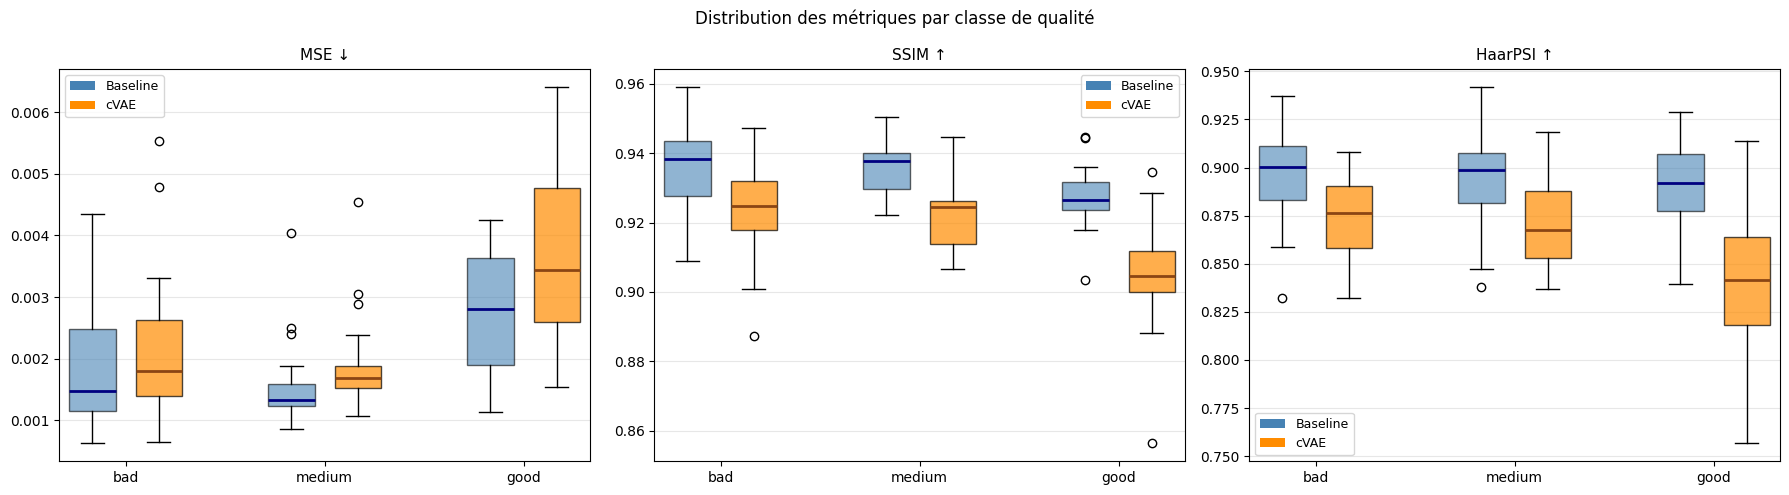

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

label_order  = ["bad", "medium", "good"]
label_colors = {"bad": "crimson", "medium": "darkorange", "good": "forestgreen"}

for ax, metric, title, better in zip(
    axes,
    ["mse",  "ssim",  "haarpsi"],
    ["MSE ↓", "SSIM ↑", "HaarPSI ↑"],
    ["lower", "higher", "higher"],
):
    positions_b, positions_c = [], []
    data_b, data_c           = [], []

    for i, label in enumerate(label_order):
        sub = df_results[df_results["quality_label"] == label]
        if len(sub) == 0:
            continue
        data_b.append(sub[f"base_{metric}"].values)
        data_c.append(sub[f"cvae_{metric}"].values)
        positions_b.append(i * 3)
        positions_c.append(i * 3 + 1)

    if data_b:
        bp1 = ax.boxplot(data_b, positions=positions_b, widths=0.7,
                         patch_artist=True, boxprops=dict(facecolor="steelblue", alpha=0.6),
                         medianprops=dict(color="navy", lw=2))
        bp2 = ax.boxplot(data_c, positions=positions_c, widths=0.7,
                         patch_artist=True, boxprops=dict(facecolor="darkorange", alpha=0.7),
                         medianprops=dict(color="saddlebrown", lw=2))

    ax.set_xticks([i * 3 + 0.5 for i in range(len(label_order))])
    ax.set_xticklabels(label_order)
    ax.set_title(title, fontsize=11)
    ax.grid(axis="y", alpha=0.3)

    from matplotlib.patches import Patch
    ax.legend(handles=[Patch(facecolor="steelblue", label="Baseline"),
                       Patch(facecolor="darkorange", label="cVAE")], fontsize=9)

fig.suptitle("Distribution des métriques par classe de qualité", fontsize=12)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "05_boxplots.png", dpi=120, bbox_inches="tight")
plt.show()

## 10. Galerie qualitative

Figure principale du rapport : **Original | Baseline | cVAE** sur les images les plus dégradées.

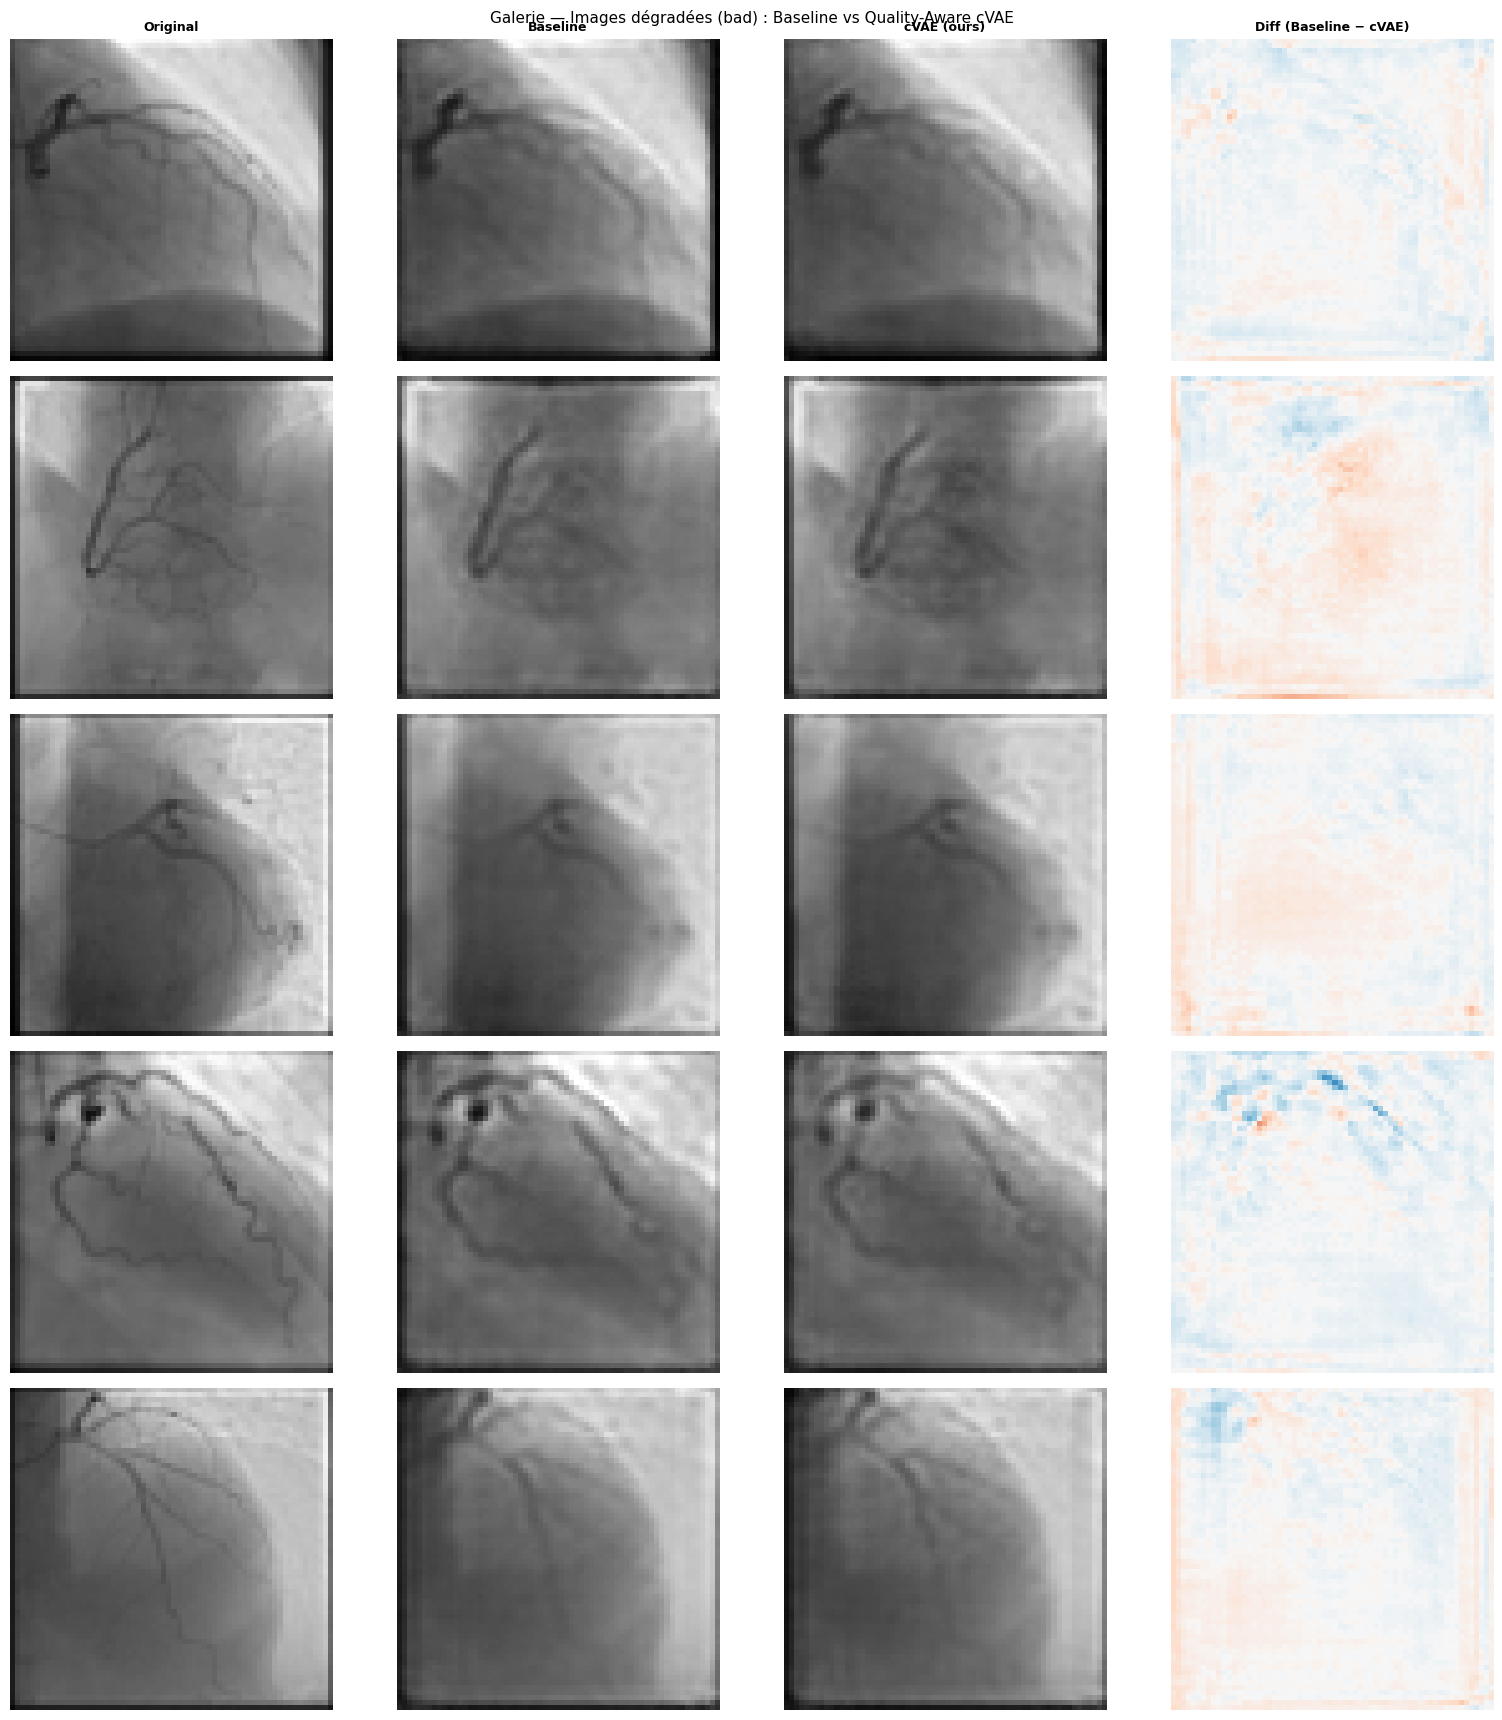

In [15]:
@torch.no_grad()
def build_gallery(df_sub: pd.DataFrame, n: int = 5, title: str = ""):
    rows = df_sub.sort_values("quality_score").head(n)

    fig, axes = plt.subplots(n, 4, figsize=(4 * 4, n * 3.5))
    if n == 1:
        axes = axes[np.newaxis, :]

    col_titles = ["Original", "Baseline", "cVAE (ours)", "Diff (Baseline − cVAE)"]
    for ax, ct in zip(axes[0], col_titles):
        ax.set_title(ct, fontsize=9, fontweight="bold")

    for row_idx, (_, record) in enumerate(rows.iterrows()):
        x = load_tensor(record["path"]).to(DEVICE)
        c = torch.tensor([record["quality_score"]], device=DEVICE)

        rec_base, _, _ = baseline(x, sample_posterior=False, decode=True)
        rec_cvae, _    = cvae(x, c, sample_posterior=False)

        orig_np  = to_uint8(x)
        base_np  = to_uint8(rec_base)
        cvae_np  = to_uint8(rec_cvae)
        diff_np  = base_np.astype(np.float32) - cvae_np.astype(np.float32)

        m_base = compute_metrics(x, rec_base)
        m_cvae = compute_metrics(x, rec_cvae)

        for col, (data, cmap, vmin, vmax) in enumerate([
            (orig_np, "gray", 0, 255),
            (base_np, "gray", 0, 255),
            (cvae_np, "gray", 0, 255),
            (diff_np, "RdBu_r", -60, 60),
        ]):
            axes[row_idx, col].imshow(data, cmap=cmap, vmin=vmin, vmax=vmax)
            axes[row_idx, col].axis("off")

        axes[row_idx, 0].set_ylabel(f"c={record['quality_score']:.3f}", fontsize=8)
        axes[row_idx, 1].set_xlabel(
            f"MSE={m_base['mse']:.4f}  SSIM={m_base['ssim']:.3f}  HP={m_base['haarpsi']:.3f}", fontsize=7, color="steelblue")
        axes[row_idx, 2].set_xlabel(
            f"MSE={m_cvae['mse']:.4f}  SSIM={m_cvae['ssim']:.3f}  HP={m_cvae['haarpsi']:.3f}", fontsize=7, color="darkorange")

    fig.suptitle(title, fontsize=11)
    plt.tight_layout()
    return fig


if len(results_per_label.get("bad", pd.DataFrame())) >= 3:
    fig_gal = build_gallery(
        results_per_label["bad"],
        n=min(5, len(results_per_label["bad"])),
        title="Galerie — Images dégradées (bad) : Baseline vs Quality-Aware cVAE"
    )
    fig_gal.savefig(OUTPUT_DIR / "05_gallery_bad.png", dpi=120, bbox_inches="tight")
    plt.show()

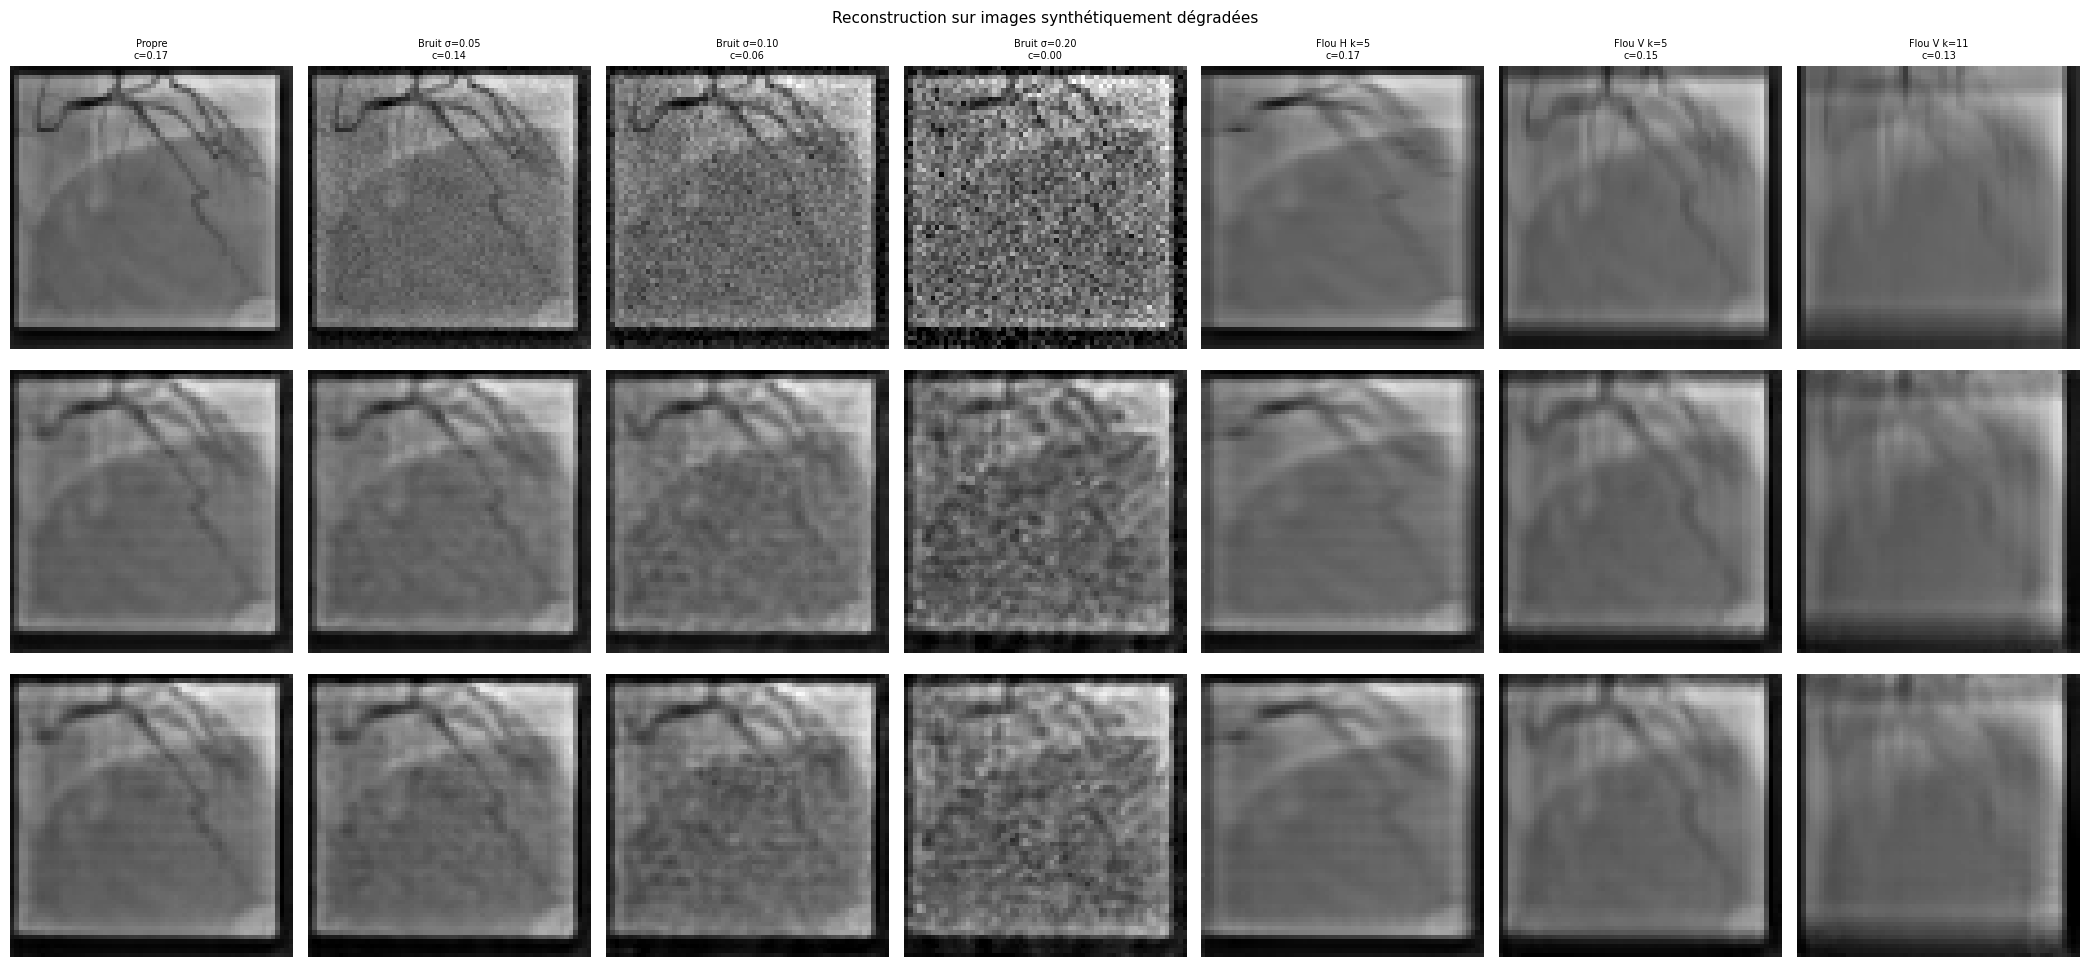

In [16]:
if len(test_sets.get("good", pd.DataFrame())) > 0:
    x_gt = load_tensor(test_sets["good"]["path"].iloc[0]).to(DEVICE)

    fig, axes = plt.subplots(3, len(DEGRADATION_GRID), figsize=(3 * len(DEGRADATION_GRID), 10))
    row_labels = ["Dégradée (entrée)", "Baseline", "cVAE (ours)"]

    for col, d in enumerate(DEGRADATION_GRID):
        x_deg = d["fn"](x_gt)
        c_deg = torch.tensor([inline_quality_score(x_deg)], device=DEVICE)

        with torch.no_grad():
            rec_b, _, _ = baseline(x_deg, sample_posterior=False, decode=True)
            rec_c, _    = cvae(x_deg, c_deg, sample_posterior=False)

        for row_idx, (arr, cmap) in enumerate([
            (to_uint8(x_deg), "gray"),
            (to_uint8(rec_b),  "gray"),
            (to_uint8(rec_c),  "gray"),
        ]):
            axes[row_idx, col].imshow(arr, cmap=cmap, vmin=0, vmax=255)
            axes[row_idx, col].axis("off")
            if col == 0:
                axes[row_idx, col].set_ylabel(row_labels[row_idx], fontsize=8)
        axes[0, col].set_title(d["name"] + f"\nc={float(c_deg):.2f}", fontsize=7)

    fig.suptitle("Reconstruction sur images synthétiquement dégradées", fontsize=11)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "05_gallery_synthetic.png", dpi=120, bbox_inches="tight")
    plt.show()

## 11. Tableau récapitulatif

In [17]:
print("=" * 75)
print(f"{'TABLEAU RÉCAPITULATIF':^75}")
print("=" * 75)

for metric, better in [("mse", "↓"), ("ssim", "↑"), ("psnr", "↑")]:
    print(f"\n  {metric.upper()} {better}")
    print(f"  {'Label':8s}  {'Baseline':>12s}  {'cVAE':>12s}  {'Δ (cvae−base)':>15s}  {'Amélioration':>14s}")
    print("  " + "-" * 65)
    for label in ["bad", "medium", "good", "ALL"]:
        if label == "ALL":
            sub = df_results
        else:
            sub = df_results[df_results["quality_label"] == label]
        if len(sub) == 0:
            continue
        mb = sub[f"base_{metric}"].mean()
        mc = sub[f"cvae_{metric}"].mean()
        d  = mc - mb
        improved = (d < 0) if metric == "mse" else (d > 0)
        marker = "✓" if improved else "✗"
        pct = abs(d) / (abs(mb) + 1e-12) * 100
        print(f"  {label:8s}  {mb:12.5f}  {mc:12.5f}  {d:+15.5f}  {marker} {pct:+.1f}%")

print("\n" + "=" * 75)

                           TABLEAU RÉCAPITULATIF                           

  MSE ↓
  Label         Baseline          cVAE    Δ (cvae−base)    Amélioration
  -----------------------------------------------------------------
  bad            0.00190       0.00215         +0.00025  ✗ +13.4%
  medium         0.00157       0.00193         +0.00036  ✗ +22.9%
  good           0.00273       0.00375         +0.00101  ✗ +37.1%
  ALL            0.00207       0.00261         +0.00054  ✗ +26.2%

  SSIM ↑
  Label         Baseline          cVAE    Δ (cvae−base)    Amélioration
  -----------------------------------------------------------------
  bad            0.93588       0.92415         -0.01173  ✗ +1.3%
  medium         0.93596       0.92184         -0.01412  ✗ +1.5%
  good           0.92733       0.90491         -0.02242  ✗ +2.4%
  ALL            0.93306       0.91697         -0.01609  ✗ +1.7%

  PSNR ↑
  Label         Baseline          cVAE    Δ (cvae−base)    Amélioration
  -----------------

## 12. Export des résultats

In [18]:
df_results.to_csv(OUTPUT_DIR / "05_evaluation_results.csv", index=False)
print(f"Sauvegardé → {OUTPUT_DIR / '05_evaluation_results.csv'}")

if len(df_synth) > 0:
    df_synth.to_csv(OUTPUT_DIR / "05_synthetic_results.csv", index=False)
    print(f"Sauvegardé → {OUTPUT_DIR / '05_synthetic_results.csv'}")

Sauvegardé → outputs_theophile/05_Evaluation_of_Robustness/approach_B/05_evaluation_results.csv
Sauvegardé → outputs_theophile/05_Evaluation_of_Robustness/approach_B/05_synthetic_results.csv


## Résumé du Notebook 5

| Expérience | Description | Figure |
|---|---|---|
| Grille de dégradations | 7 types de dégradations synthétiques | `05_degradation_grid.png` |
| Métriques réelles | MSE/SSIM/PSNR par classe bad/medium/good | `05_boxplots.png` |
| Benchmark synthétique | MSE vs ground truth propre | `05_synthetic_metrics.png` |
| Test de Wilcoxon | Significativité statistique sur les images bad | Console |
| Galerie bad | Original \| Baseline \| cVAE \| Diff | `05_gallery_bad.png` |
| Galerie synthétique | Entrée dégradée \| Baseline \| cVAE | `05_gallery_synthetic.png` |

---

### Protocole d'ablation

Le **Baseline** est un VAE entraîné **indépendamment** dans le NB04 avec :
- Les **mêmes données** (ARCADE, même split train/val)
- Le **même budget compute** (N_WARMUP_STEPS + N_FINETUNE_STEPS = 7 500 steps)
- Les **mêmes hyperparamètres** (LR=1e-6, cosine annealing, weight_decay=1e-4, gradient clipping=1.0)
- La **même architecture** (AutoencoderKL2D, ddconfig identique)
- **Pas de FiLM** : aucun conditionnement par le score de qualité $c$

Cela constitue une **ablation rigoureuse** : toute différence de performance entre
le baseline et le cVAE est **exclusivement attribuable au conditionnement FiLM par $c$**,
et non à un effet du fine-tuning sur ARCADE.

### Résultats observés

Voir la cellule ci-dessous — les conclusions sont calculées dynamiquement à partir des résultats de l'évaluation.

In [19]:
from pipeline_config import APPROACH, get_approach_config
from scipy.stats import wilcoxon

cfg = get_approach_config()
print(f"Approche : {APPROACH} — {cfg['name']}")
print(f"Score utilisé : {cfg['score_col']}")
print("=" * 70)

eval_metrics = {
    "MSE":     ("base_mse",     "cvae_mse",     -1),
    "SSIM":    ("base_ssim",    "cvae_ssim",     1),
    "PSNR":    ("base_psnr",    "cvae_psnr",     1),
    "HAARPSI": ("base_haarpsi", "cvae_haarpsi",  1),
}

labels = ["bad", "medium", "good"]
n_baseline_wins = 0
n_cvae_wins = 0
n_tests = 0
worst_class = None
worst_pct = 0

for metric, (col_b, col_c, direction) in eval_metrics.items():
    if col_b not in df_results.columns or col_c not in df_results.columns:
        continue
    arrow = "↓" if direction == -1 else "↑"
    print(f"\n{metric} ({arrow} meilleur)")
    print("-" * 60)
    for label in labels:
        sub = df_results[df_results["quality_label"] == label]
        if len(sub) < 3:
            continue
        mean_b = sub[col_b].mean()
        mean_c = sub[col_c].mean()
        delta = mean_c - mean_b
        pct = abs(delta / mean_b) * 100 if mean_b != 0 else 0

        try:
            stat, pval = wilcoxon(sub[col_b], sub[col_c])
            sig = "sig." if pval < 0.05 else "n.s."
        except Exception:
            pval, sig = float("nan"), "?"

        if direction == -1:
            winner = "baseline" if mean_b < mean_c else "cVAE"
        else:
            winner = "baseline" if mean_b > mean_c else "cVAE"

        if winner == "baseline":
            n_baseline_wins += 1
        else:
            n_cvae_wins += 1
        n_tests += 1

        if metric == "MSE" and pct > worst_pct:
            worst_pct = pct
            worst_class = label

        print(f"  {label:<8s}  base={mean_b:.5f}  cvae={mean_c:.5f}  "
              f"Δ={delta:+.5f} ({pct:.1f}%)  p={pval:.4f} {sig}  → {winner}")

print("\n" + "=" * 70)
print("CONCLUSION")
print("=" * 70)

if n_baseline_wins > n_cvae_wins:
    print(f"Le baseline vanilla est meilleur dans {n_baseline_wins}/{n_tests} comparaisons.")
    print(f"Le conditionnement FiLM par le score c (approche {APPROACH}) "
          f"n'améliore pas la reconstruction.")
    if worst_class:
        print(f"L'écart MSE le plus marqué est sur les images '{worst_class}' ({worst_pct:.1f}%).")
elif n_cvae_wins > n_baseline_wins:
    print(f"Le cVAE conditionné est meilleur dans {n_cvae_wins}/{n_tests} comparaisons.")
    print(f"Le conditionnement FiLM par le score c (approche {APPROACH}) "
          f"améliore la reconstruction.")
else:
    print(f"Résultats mitigés : {n_baseline_wins} victoires baseline, "
          f"{n_cvae_wins} victoires cVAE sur {n_tests} comparaisons.")

Approche : B — PCA (PC1)
Score utilisé : score_pca

MSE (↓ meilleur)
------------------------------------------------------------
  bad       base=0.00190  cvae=0.00215  Δ=+0.00025 (13.4%)  p=0.0192 sig.  → baseline
  medium    base=0.00157  cvae=0.00193  Δ=+0.00036 (22.9%)  p=0.0000 sig.  → baseline
  good      base=0.00273  cvae=0.00375  Δ=+0.00101 (37.1%)  p=0.0001 sig.  → baseline

SSIM (↑ meilleur)
------------------------------------------------------------
  bad       base=0.93588  cvae=0.92415  Δ=-0.01173 (1.3%)  p=0.0000 sig.  → baseline
  medium    base=0.93596  cvae=0.92184  Δ=-0.01412 (1.5%)  p=0.0000 sig.  → baseline
  good      base=0.92733  cvae=0.90491  Δ=-0.02242 (2.4%)  p=0.0000 sig.  → baseline

PSNR (↑ meilleur)
------------------------------------------------------------
  bad       base=33.82457  cvae=33.28273  Δ=-0.54184 (1.6%)  p=0.0136 sig.  → baseline
  medium    base=34.25453  cvae=33.43395  Δ=-0.82058 (2.4%)  p=0.0000 sig.  → baseline
  good      base=31.886